# Dataset EDA\n
\n
Reads `structured_csv_data_files/fetched_data/dataset.csv` and runs quick, dependency-light checks.

In [ ]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parent.parent  # notebooks/EDA -> repo root 
DATASET_CSV = REPO_ROOT / "structured_csv_data_files" / "fetched_data" / "dataset.csv"
DATASET_CSV

PosixPath('/Users/shaunaksoni/Cursor/ML Project/ml-weekend-gap-prediction/structured_csv_data_files/fetched_data/dataset.csv')

In [2]:
df = pd.read_csv(DATASET_CSV)
df.shape

(64210, 39)

In [3]:
df.head(10)

,Year,Quarter,Date,Ticker,Open,Close,High,Low,Volume,Revenues,...,BollingerBandWidth,ATR,FiveDStdDev,OBV,MFI,VolumeRatio,GrossMargin,NetMargin,RoA,RevGrowthQoQ
0,2016,Q1,2016-03-28 00:00:00-04:00,CRM,71.521001,71.086281,71.807521,70.552770,2688100,1.916603e+09,...,NaN,NaN,NaN,0,NaN,1.089821,0.741,0.020,0.003,NaN
1,2016,Q1,2016-03-29 00:00:00-04:00,CRM,70.681204,71.432083,71.817401,69.861166,4606100,1.916603e+09,...,NaN,NaN,NaN,4606100,NaN,1.089821,0.741,0.020,0.003,0.0
2,2016,Q1,2016-03-30 00:00:00-04:00,CRM,72.123676,73.408073,73.763752,72.084155,5181100,1.916603e+09,...,NaN,NaN,NaN,9787200,NaN,1.089821,0.741,0.020,0.003,0.0
3,2016,Q1,2016-03-31 00:00:00-04:00,CRM,73.170953,72.943718,73.496993,72.499115,4226900,1.916603e+09,...,NaN,NaN,NaN,5560300,NaN,1.089821,0.741,0.020,0.003,0.0
4,2016,Q2,2016-04-01 00:00:00-04:00,CRM,72.499112,74.820908,75.038260,72.232356,4550600,2.036618e+09,...,NaN,1.869287,NaN,10110900,52.955228,1.089821,0.742,0.113,0.016,NaN
5,2016,Q2,2016-04-04 00:00:00-04:00,CRM,74.939463,74.781387,75.522384,74.504750,2978100,2.036618e+09,...,NaN,1.821864,0.015515,7132800,59.623733,0.846914,0.742,0.113,0.016,0.0
6,2016,Q2,2016-04-05 00:00:00-04:00,CRM,73.981109,73.684715,74.603552,73.467355,2365400,2.036618e+09,...,NaN,1.693423,0.019233,4767400,66.011771,0.846914,0.742,0.113,0.016,0.0
7,2016,Q2,2016-04-06 00:00:00-04:00,CRM,73.862543,74.672699,74.771497,73.576023,2033300,2.036618e+09,...,NaN,1.466184,0.016088,6800700,59.538483,0.846914,0.742,0.113,0.016,0.0
8,2016,Q2,2016-04-07 00:00:00-04:00,CRM,74.010751,74.415825,74.554144,73.783508,3843700,2.036618e+09,...,NaN,1.444447,0.015693,2957000,60.711499,0.846914,0.742,0.113,0.016,0.0
9,2016,Q2,2016-04-08 00:00:00-04:00,CRM,74.811028,73.951469,75.028389,73.408076,2375700,2.036618e+09,...,NaN,1.207329,0.010242,581300,37.036823,0.846914,0.742,0.113,0.016,0.0


In [4]:
df.dtypes.sort_index()

ADX                    float64
ATR                    float64
Assets                   int64
BollingerBandWidth     float64
Close                  float64
CloseVEma50            float64
CloseVSma20            float64
CostOfRevenues         float64
Date                    object
Equity                 float64
FiveDStdDev            float64
FridayPosition         float64
GrossMargin            float64
GrossProfit            float64
High                   float64
IntraWeekVolatility    float64
Liabilities            float64
Low                    float64
MACD                   float64
MFI                    float64
NetIncome              float64
NetMargin              float64
OBV                      int64
Open                   float64
OpenCloseSpread        float64
Quarter                 object
ROC                    float64
RSI                    float64
RevGrowthQoQ           float64
Revenues               float64
RoA                    float64
Shares                 float64
StochPer

In [ ]:
# Missingness (top 30 columns) 
(df.isna().mean().sort_values(ascending=False).head(30))

Liabilities           0.234854
GrossMargin           0.160925
CostOfRevenues        0.160925
GrossProfit           0.160925
MFI                   0.133842
RSI                   0.108441
WeeklyReturn          0.107896
WeeklyRange           0.085781
ADX                   0.028454
VolumeRatio           0.022115
OpenCloseSpread       0.022115
FridayPosition        0.022115
Shares                0.017723
RevGrowthQoQ          0.013985
BollingerBandWidth    0.007398
CloseVSma20           0.007398
FiveDStdDev           0.001947
ROC                   0.001947
ATR                   0.001557
StochPercK            0.001557
Assets                0.000000
Close                 0.000000
RoA                   0.000000
NetMargin             0.000000
Date                  0.000000
Ticker                0.000000
Open                  0.000000
OBV                   0.000000
CloseVEma50           0.000000
Equity                0.000000
dtype: float64

In [ ]:
# Basic uniqueness checks 
{
    "n_rows": len(df),
    "n_tickers": df["Ticker"].nunique() if "Ticker" in df.columns else None,
    "n_dates": df["Date"].nunique() if "Date" in df.columns else None,
}

{'n_rows': 64210, 'n_tickers': 25, 'n_dates': 2207}

In [ ]:
# Parse Date if present (your CSV stores timezone info in the string) 
if "Date" in df.columns:
    df["Date_parsed"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
    display(df[["Date", "Date_parsed"]].head(5))
    display(df["Date_parsed"].describe())

,Date,Date_parsed
0,2016-03-28 00:00:00-04:00,2016-03-28 04:00:00+00:00
1,2016-03-29 00:00:00-04:00,2016-03-29 04:00:00+00:00
2,2016-03-30 00:00:00-04:00,2016-03-30 04:00:00+00:00
3,2016-03-31 00:00:00-04:00,2016-03-31 04:00:00+00:00
4,2016-04-01 00:00:00-04:00,2016-04-01 04:00:00+00:00


count                                  64210
mean     2020-08-25 02:46:41.059025152+00:00
min                2016-03-28 04:00:00+00:00
25%                2018-07-17 04:00:00+00:00
50%                2020-08-13 04:00:00+00:00
75%                2022-10-06 04:00:00+00:00
max                2024-12-31 05:00:00+00:00
Name: Date_parsed, dtype: object

In [ ]:
# Rows per ticker (top 25) 
if "Ticker" in df.columns:
    df["Ticker"].value_counts().head(25)

In [ ]:
# (Ticker, Year, Quarter) grain sanity check 
if {"Ticker", "Year", "Quarter"}.issubset(df.columns):
    n_unique = df[["Ticker", "Year", "Quarter"]].drop_duplicates().shape[0]
    display({"unique_ticker_year_quarter": n_unique})
    display(df[["Ticker", "Year", "Quarter"]].value_counts().head(10))

{'unique_ticker_year_quarter': 898}

Ticker  Year  Quarter
ADSK    2019  Q3         256
CPAY    2021  Q2         252
        2020  Q2         252
ADSK    2018  Q3         252
CPAY    2018  Q1         244
        2019  Q1         244
GWRE    2021  Q3         192
SSNC    2019  Q3         192
GWRE    2019  Q3         192
CPAY    2019  Q3         192
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

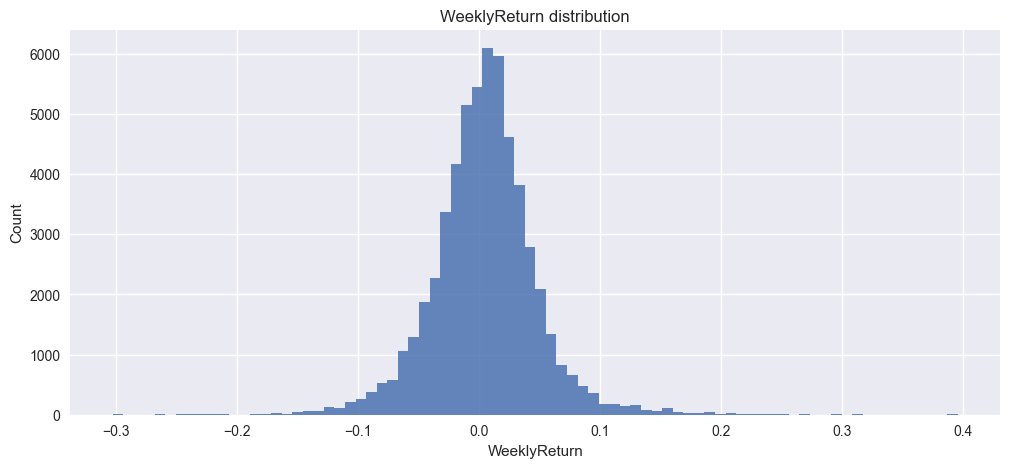

In [11]:
# WeeklyReturn distribution
if "WeeklyReturn" in df.columns:
    s = pd.to_numeric(df["WeeklyReturn"], errors="coerce").dropna()
    plt.hist(s, bins=80, alpha=0.85)
    plt.title("WeeklyReturn distribution")
    plt.xlabel("WeeklyReturn")
    plt.ylabel("Count")
    plt.show()

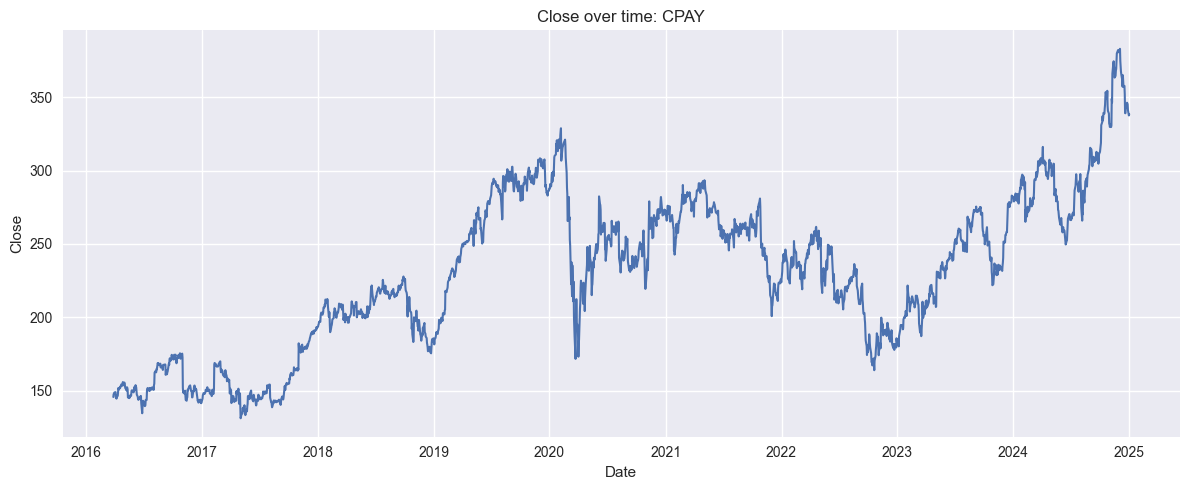

In [12]:
# Close price time series for a sample ticker
if {"Ticker", "Close", "Date_parsed"}.issubset(df.columns):
    sample_ticker = df["Ticker"].value_counts().index[0]
    dft = df.loc[df["Ticker"] == sample_ticker, ["Date_parsed", "Close"]].dropna().sort_values("Date_parsed")
    plt.plot(dft["Date_parsed"], dft["Close"], linewidth=1.5)
    plt.title(f"Close over time: {sample_ticker}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.tight_layout()
    plt.show()

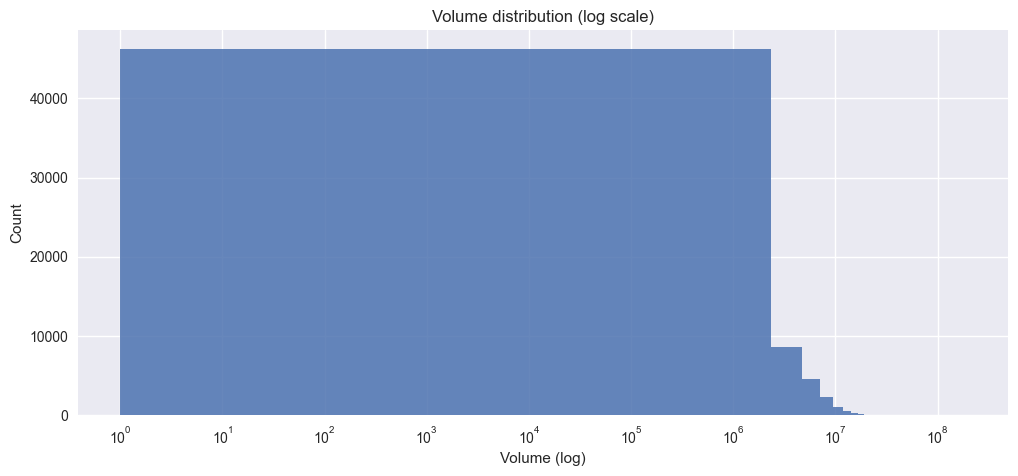

In [13]:
# Volume distribution (log scale helps) and outlier check
if "Volume" in df.columns:
    v = pd.to_numeric(df["Volume"], errors="coerce").dropna()
    plt.hist(v.clip(lower=1), bins=80, alpha=0.85)
    plt.xscale("log")
    plt.title("Volume distribution (log scale)")
    plt.xlabel("Volume (log)")
    plt.ylabel("Count")
    plt.show()

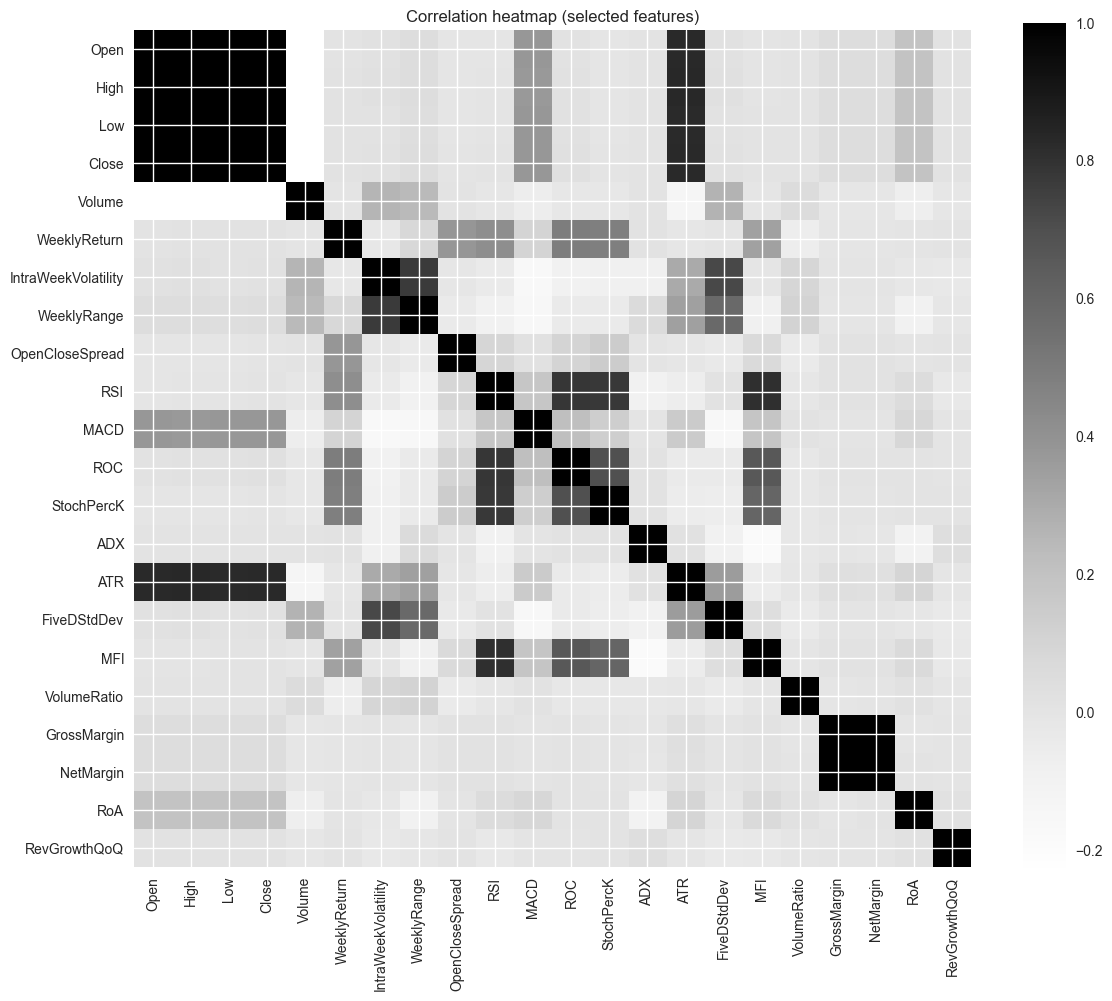

In [14]:
# Correlation heatmap for a small, relevant numeric subset
numeric_cols = df.select_dtypes(include=["number"]).columns
preferred = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "WeeklyReturn",
    "IntraWeekVolatility",
    "WeeklyRange",
    "OpenCloseSpread",
    "RSI",
    "MACD",
    "ROC",
    "StochPercK",
    "ADX",
    "ATR",
    "FiveDStdDev",
    "MFI",
    "VolumeRatio",
    "GrossMargin",
    "NetMargin",
    "RoA",
    "RevGrowthQoQ",
]
cols = [c for c in preferred if c in numeric_cols]

if len(cols) >= 5:
    corr = df[cols].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    plt.imshow(corr, interpolation="nearest")
    plt.title("Correlation heatmap (selected features)")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()